In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import sys
from pathlib import Path
import mlflow
import os
import joblib
import logging

# Loading & Splits

## Loading

### Loading logger

In [33]:
# Loading logger
LOG_DIR = PROJECT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "model_notebook.log"

logging.basicConfig(
    level= logging.INFO,
    format= "%(asctime)s | %(levelname)s | %(message)s",
    datefmt= "%d-%m-%Y %H:%M:%S",
    handlers= [
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

logger.info("Jupyter Notebook model_evaluation.ipynb")

21-06-2026 02:42:58 | INFO | Jupyter Notebook model_evaluation.ipynb


### Loading config and path

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

FEATURES_PATH = PROJECT_ROOT / config["data"]["features_path"]

# Splits
V1_TRAIN_START = config["splits"]["v1_train_start"]
V1_TRAIN_END = config["splits"]["v1_train_end"]
V1_VAL_START = config["splits"]["v1_val_start"]
V1_VAL_END = config["splits"]["v1_val_end"]
V1_TEST_START = config["splits"]["v1_test_start"]
V1_TEST_END = config["splits"]["v1_test_end"]

RANDOM_STATE = config["random_state"]

print("Config loaded")
print(f"Features Path : {FEATURES_PATH}")

Config loaded
Features Path : C:\Users\HP\Documents\Fraud_Detection_System\data\features\features.parquet


### Loading Features

In [3]:
print("Loading Features ...")
df = pd.read_parquet(FEATURES_PATH)

print(f"Shape : {df.shape}")
print(f"Rows : {len(df):,}")
print(f"Columnns : {df.shape[1]}")
print(f"Timestamp range : {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Fraud Rate : {df['is_fraud'].mean():.6f}")
print(f"Nulls : {df.isna().sum().sum()}")
print(f"Columns in df : \n{df.columns.tolist()}")

Loading Features ...
Shape : (24386678, 47)
Rows : 24,386,678
Columnns : 47
Timestamp range : 1991-01-02 07:10:00 to 2020-02-28 23:58:00
Fraud Rate : 0.001220
Nulls : 0
Columns in df : 
['user_id', 'card', 'timestamp', 'amount', 'is_refund', 'mcc', 'use_chip', 'merchant_name', 'merchant_city', 'merchant_state', 'is_fraud', 'is_high_value', 'error_bad_cvv', 'error_bad_expiration', 'error_bad_card', 'error_bad_pin', 'day_of_week', 'is_weekend', 'is_night', 'hour_sin', 'hour_cos', 'minutes_since_last_txn', 'mcc_frequency', 'card_txn_count_60min', 'card_txn_count_1440min', 'card_txn_count_30d', 'card_txn_count_365d', 'card_spend_mean_30d', 'card_spend_std_30d', 'user_txn_count_60min', 'user_txn_count_1440min', 'user_txn_count_30d', 'user_txn_count_365d', 'user_spend_mean_30d', 'user_spend_std_30d', 'card_amount_zscore_30d', 'user_amount_zscore_30d', 'card_amount_zscore_365d', 'user_amount_zscore_365d', 'card_is_new_merchant', 'user_is_new_merchant', 'distinct_cards_used_1440min', 'card_is_

## Feature Groups

In [4]:
velocity_card_cols = ['card_txn_count_60min', 'card_txn_count_1440min', 
                      'card_txn_count_30d', 'card_txn_count_365d']

spend_card_cols = ['card_spend_mean_30d', 'card_spend_std_30d']

velocity_user_cols = ['user_txn_count_60min', 'user_txn_count_1440min', 
                     'user_txn_count_30d', 'user_txn_count_365d']

spend_user_cols = ['user_spend_mean_30d', 'user_spend_std_30d']

zscore_features = ["card_amount_zscore_30d", "user_amount_zscore_30d", 
                   "card_amount_zscore_365d", "user_amount_zscore_365d"]

geo_features = ["card_is_new_state", "user_is_new_state", "card_is_new_city", 
            "user_is_new_city"]

In [5]:
feature_groups = {
    "Raw" : ["amount", "is_refund", "is_high_value", "is_online", "error_bad_cvv", 
             "error_bad_expiration", "error_bad_card", "error_bad_pin"],
    
    "Temporal" : ["day_of_week", "is_weekend", "is_night", "hour_sin", 
                  "hour_cos", "minutes_since_last_txn"],

    "MCC Encoding" : ["mcc_frequency"],

    "Card Velocity" : velocity_card_cols,
    "Card Spend" : spend_card_cols,

    "User Velocity" : velocity_user_cols,
    "User Spend" : spend_user_cols,

    "Z-Scores" : zscore_features,

    "Merchant Familiarity" : ["card_is_new_merchant", "user_is_new_merchant"],

    "Cross-Card" : ["distinct_cards_used_1440min"],

    "Geographical" : geo_features
}

In [6]:
FEATURE_COLS = [col for group in feature_groups.values() for col in group]

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"Missing Columns : {missing}")

print(f"\nFeature Groups :")
for group, col in feature_groups.items():
    print(f"{group : <25}{len(col)} features")

print(f"\nTotal Features : {len(FEATURE_COLS)}")
print("Target : is_fraud")


Feature Groups :
Raw                      8 features
Temporal                 6 features
MCC Encoding             1 features
Card Velocity            4 features
Card Spend               2 features
User Velocity            4 features
User Spend               2 features
Z-Scores                 4 features
Merchant Familiarity     2 features
Cross-Card               1 features
Geographical             4 features

Total Features : 38
Target : is_fraud


## V1 Train / Val / Test Split

In [7]:
year = df["timestamp"].dt.year

v1_train = df[(year >= V1_TRAIN_START) & (year <= V1_TRAIN_END)]
v1_val = df[(year >= V1_VAL_START) & (year <= V1_VAL_END)]
v1_test = df[(year >= V1_TEST_START) & (year <= V1_TEST_END)]

x_train = v1_train[FEATURE_COLS]
y_train = v1_train["is_fraud"]

x_val = v1_val[FEATURE_COLS]
y_val = v1_val["is_fraud"]

x_test = v1_test[FEATURE_COLS]
y_test = v1_test["is_fraud"]

print("V1 Splits : \n")
print(f"{'Splits':<6}{'Rows':>10}{'Fraud':>8}{'Non Fraud':>12}{'Fraud Rate':>12}")

for name, x, y in [
    ("Train", x_train, y_train),
    ("Val", x_val, y_val),
    ("Test", x_test, y_test)
]:
    fraud_count = y.sum()
    non_fraud_count = len(y) - fraud_count
    fraud_rate = y.mean()
    print(f"{name:<6}{len(y):>10,}{fraud_count:>8,}{non_fraud_count:>12,}{fraud_rate:>10.5f}")

V1 Splits : 

Splits      Rows   Fraud   Non Fraud  Fraud Rate
Train  8,966,456  13,606   8,952,850   0.00152
Val    3,181,346   1,388   3,179,958   0.00044
Test   3,323,230   3,070   3,320,160   0.00092


# Models

## LightGBM

### Baseline LightGBM

In [8]:
import lightgbm as lgb

SCALE_POS_WEIGHT = config["model"]["lgbm"]["baseline"]["scale_pos_weight"]

baseline_parameters = {
    "objective" : config["model"]["lgbm"]["baseline"]["objective"],
    "metric" : config["model"]["lgbm"]["baseline"]["metric"],
    "learning_rate" : config["model"]["lgbm"]["baseline"]["learning_rate"],
    "max_depth" : config["model"]["lgbm"]["baseline"]["max_depth"],
    "n_estimators" : config["model"]["lgbm"]["baseline"]["n_estimators"],
    "scale_pos_weight" : SCALE_POS_WEIGHT,
    "random_state" : RANDOM_STATE,
    "verbosity" : -1
}

print("Training baseline LightGBM ...")
print(f"Parameters : \n{baseline_parameters}\n")

baseline_model = lgb.LGBMClassifier(**baseline_parameters)
baseline_model.fit(
    x_train, y_train,
    eval_set = [(x_val, y_val)]
)

print("\nBaseline LightGBM Trained")

Training baseline LightGBM ...
Parameters : 
{'objective': 'binary', 'metric': 'aucpr', 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500, 'scale_pos_weight': 649.4353, 'random_state': 42, 'verbosity': -1}


Baseline LightGBM Trained


### Baseline Model Evaluation

In [34]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    recall_score, precision_score, roc_curve
)

from src.models.model_utils import evaluate_model
    
baseline_val_prob, baseline_val_metrics = evaluate_model(
    baseline_model, x_val, y_val, split_name="Baseline Val"
)

21-06-2026 02:44:16 | INFO | Baseline Val Evaluation (threshold = 0.5):

21-06-2026 02:44:16 | INFO | pr_auc             : 0.00434
21-06-2026 02:44:16 | INFO | roc_auc            : 0.87257
21-06-2026 02:44:16 | INFO | f1                 : 0.00820
21-06-2026 02:44:16 | INFO | recall             : 0.86599
21-06-2026 02:44:16 | INFO | precision          : 0.00412
21-06-2026 02:44:16 | INFO | fpr                : 0.09137
21-06-2026 02:44:16 | INFO | recall_at_0.1%fpr  : 0.00000
21-06-2026 02:44:16 | INFO | recall_at_1%fpr    : 0.00000
21-06-2026 02:44:16 | INFO | precision_top_1k   : 0.00000
21-06-2026 02:44:16 | INFO | precision_top_5k   : 0.00100
21-06-2026 02:44:16 | INFO | precision_top_10k  : 0.00110


### Hyperparameter Tuning using Optuna

In [11]:
# Creating Sample for Hyperparameter Tuning (Stratified)

SAMPLE_SIZE = 1_000_000

fraud_idx = x_train[y_train == 1].index
non_fraud_idx = x_train[y_train == 0].index

# Keeping scale_pos_weight same & sampling Frauds and Non-Frauds
tune_fraud_count = int(SAMPLE_SIZE * y_train.mean())
tune_non_fraud_count = SAMPLE_SIZE - tune_fraud_count

tune_idx = np.concatenate([
    np.random.RandomState(RANDOM_STATE).choice(fraud_idx, tune_fraud_count, replace=False),
    np.random.RandomState(RANDOM_STATE).choice(non_fraud_idx, tune_non_fraud_count, replace=False)
])

x_train_tune = x_train.loc[tune_idx]
y_train_tune = y_train.loc[tune_idx]

print(f"Tune Sample Size : {len(x_train_tune):,}")
print(f"Full Fraud Count : {y_train.sum():,}")
print(f"Tune Fraud Count : {tune_fraud_count:,}")
print(f"Tune Non-Fraud Count : {tune_non_fraud_count:,}")

print(f"\nFull Fraud Rate : {y_train.mean():.6f}")
print(f"Tune Fraud Rate : {y_train_tune.mean():.6f}")

print(f"\nscale_pos_weight (full & tune) : {SCALE_POS_WEIGHT}")

Tune Sample Size : 1,000,000
Full Fraud Count : 13,606
Tune Fraud Count : 1,517
Tune Non-Fraud Count : 998,483

Full Fraud Rate : 0.001517
Tune Fraud Rate : 0.001517

scale_pos_weight (full & tune) : 649.4353


In [12]:
# Val for Tuning with Early Stopping
VAL_TUNE_SIZE = 200_000

tune_val_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(x_val), VAL_TUNE_SIZE, replace=False
)

x_val_tune = x_val.iloc[tune_val_idx]
y_val_tune = y_val.iloc[tune_val_idx]

print(f"Full Val Size : {len(x_val):,}")
print(f"Early Stopping Val Size : {len(x_val_tune):,}")

print(f"\nFull Val Fraud Rate : {y_val.mean():.6f}")
print(f"Tune Val Fraud Rate : {y_val_tune.mean():.6f}")

Full Val Size : 3,181,346
Early Stopping Val Size : 200,000

Full Val Fraud Rate : 0.000436
Tune Val Fraud Rate : 0.000450


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):

    parameters = {
        "objective" : config["model"]["lgbm"]["baseline"]["objective"],
        "metric" : "auc",   # For Tuning only
        "scale_pos_weight" : SCALE_POS_WEIGHT,
        "random_state" : RANDOM_STATE,
        "reg_alpha" : 0,
        "reg_lambda" : 1e-6,
        "verbosity" : -1,
        "n_jobs" : -1,

        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.035, log=True),
        "max_depth" : trial.suggest_int("max_depth", 6, 10),
        "n_estimators" : trial.suggest_int("n_estimators", 800, 2000, step=150),
        "num_leaves" : trial.suggest_int("num_leaves", 31, 127),
        "feature_fraction" : trial.suggest_float("feature_fraction", 0.6, 1.0),
        "min_child_samples" : trial.suggest_int("min_child_samples", 30, 100),
    }

    model = lgb.LGBMClassifier(**parameters)
    model.fit(
        x_train_tune, y_train_tune,
        eval_set = [(x_val_tune, y_val_tune)],
        eval_metric="auc",   # For Early Stopping
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),  # Early Stopping
            lgb.log_evaluation(period=-1)
        ]
    )

    val_prob = model.predict_proba(x_val)[:,1]     # PR-AUC on full Val
    return average_precision_score(y_val, val_prob)

print("Starting Optuna Tuning ...")
print("Trials : 50")
print(f"\nTraining on subset of : {len(x_train_tune):,} Rows")
print(f"Early Stopping Val : {len(x_val_tune):,} Rows")
print("\nEarly Stopping : 50 rounds")
print("Objective : Val PR-AUC\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_pr_auc = study.best_value

print(f"\nBest Val PR-AUC : {best_pr_auc:.5f}")
print(f"Baseline PR-AUC : {baseline_val_metrics['pr_auc']:.5f}")
print(f"Improvement : {best_pr_auc - baseline_val_metrics['pr_auc']:.5f}")

print("\nBest Parameters :-")
for k, v in best_params.items():
    print(f"{k:<18} : {v}")

Starting Optuna Tuning ...
Trials : 50

Training on subset of : 1,000,000 Rows
Early Stopping Val : 200,000 Rows

Early Stopping : 50 rounds
Objective : Val PR-AUC



  0%|          | 0/50 [00:00<?, ?it/s]


Best Val PR-AUC : 0.39793
Baseline PR-AUC : 0.00434
Improvement : 0.39359

Best Parameters :-
learning_rate      : 0.017706515519014778
max_depth          : 9
n_estimators       : 950
num_leaves         : 80
feature_fraction   : 0.836965827544817
min_child_samples  : 33


### Visualizing Optuna Results

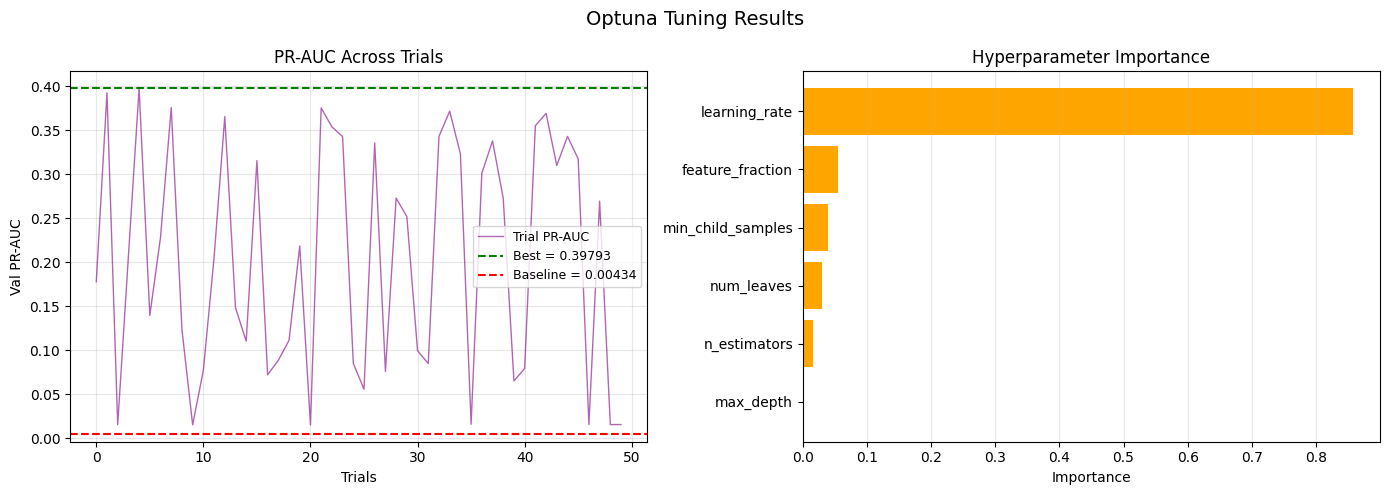

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna Tuning Results", fontsize=14)

# PR-AUC Progression
ax = axes[0]
trial_values = [t.value for t in study.trials if t.value is not None]

ax.plot(trial_values, color="purple", linewidth=1, alpha=0.6, label="Trial PR-AUC")
ax.axhline(
    best_pr_auc, color="green", linestyle="--",
    linewidth=1.5, label=f"Best = {best_pr_auc:.5f}"
)
ax.axhline(
    baseline_val_metrics["pr_auc"], color="red", linestyle="--",
    linewidth=1.5, label=f"Baseline = {baseline_val_metrics["pr_auc"]:.5f}"
)

ax.set_title("PR-AUC Across Trials")
ax.set_xlabel("Trials")
ax.set_ylabel("Val PR-AUC")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Parameter Importance
ax = axes[1]
importance = optuna.importance.get_param_importances(study)
param_list = list(importance.keys())[:8]
value_list = [importance[p] for p in param_list]

ax.barh(param_list[::-1], value_list[::-1], color="orange")
ax.set_title("Hyperparameter Importance")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Saving Tuned Parameters to Config

In [15]:
config["model"]["lgbm"]["tuned"]["learning_rate"] = best_params["learning_rate"]
config["model"]["lgbm"]["tuned"]["max_depth"] = best_params["max_depth"]
config["model"]["lgbm"]["tuned"]["n_estimators"] = best_params["n_estimators"]
config["model"]["lgbm"]["tuned"]["num_leaves"] = best_params["num_leaves"]
config["model"]["lgbm"]["tuned"]["feature_fraction"] = best_params["feature_fraction"]
config["model"]["lgbm"]["tuned"]["min_child_samples"] = best_params["min_child_samples"]
config["model"]["lgbm"]["tuned"]["reg_alpha"] = 0
config["model"]["lgbm"]["tuned"]["reg_lambda"] = 1e-6

with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Tuned parameters saved to config.yaml")

Tuned parameters saved to config.yaml


### Final LightGBM Training

In [16]:
tuned_parameters = {
    "objective" : config["model"]["lgbm"]["baseline"]["objective"],
    "metric" : config["model"]["lgbm"]["baseline"]["metric"],
    "scale_pos_weight" : SCALE_POS_WEIGHT,
    "random_state" : RANDOM_STATE,
    "verbosity" : -1,
    "n_jobs" : -1,
    **config["model"]["lgbm"]["tuned"]
}

print("Training Final LightGBM on full training data (V1) ...")
print(f"Training : {len(x_train):,} Rows")
print(f"Early Stopping Val : {len(x_val_tune):,} Rows")
print(f"\nscale_pos_weight : {SCALE_POS_WEIGHT}")
print(f"Learning Rate : {tuned_parameters['learning_rate']:.6f}")
print(f"n_estimator max : {tuned_parameters['n_estimators']}")

lgbm_v1 = lgb.LGBMClassifier(**tuned_parameters)
lgbm_v1.fit(
    x_train, y_train,
    eval_set=[(x_val_tune, y_val_tune)],
    eval_metric="auc",   # For Early Stopping
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),   # Early Stopping
        lgb.log_evaluation(period=-1)
    ]
)

utilization = lgbm_v1.best_iteration_ / tuned_parameters["n_estimators"] * 100

print("\nFinal V1 LightGBM Trained")
print(f"Best Iterartion (Trees used) : {lgbm_v1.best_iteration_}")
print(f"Utilization of trees : {utilization:.2f}%")

Training Final LightGBM on full training data (V1) ...
Training : 8,966,456 Rows
Early Stopping Val : 200,000 Rows

scale_pos_weight : 649.4353
Learning Rate : 0.017707
n_estimator max : 950

Final V1 LightGBM Trained
Best Iterartion (Trees used) : 193
Utilization of trees : 20.32%


### Evaluating Final V1 LightGBM on full Val

In [17]:
lgbm_v1_val_prob, lgbm_v1_val_metrics = evaluate_model(
    lgbm_v1, x_val, y_val, split_name="V1 Final LightGBM Val"
)

print("\n\nFinal V1 LightGBM Evaluation (full Val) :")
print("Threshold = 0.5")

print(f"\n{'Metric':<18} {'Baseline':>12} {'Final V1':>12} {'Delta':>12}")
for metric in [
    "pr_auc", "roc_auc", "f1", "recall", "precision", "fpr", "recall_at_0.1%fpr",
    "recall_at_1%fpr", "precision_top_1k", "precision_top_5k", "precision_top_10k"
]:
    baseline_val = baseline_val_metrics.get(metric, 0.0)
    final_val = lgbm_v1_val_metrics[metric]
    delta = final_val - baseline_val
    print(f"{metric:<18} {baseline_val:>12.5f} {final_val:>12.5f} {delta:>+12.5f}")

V1 Final LightGBM Val Evaluation (threshold = 0.5):

pr_auc             : 0.27048
roc_auc            : 0.97891
f1                 : 0.01766
recall             : 0.92867
precision          : 0.00892
fpr                : 0.04506
recall_at_0.1%fpr  : 0.48775
recall_at_1%fpr    : 0.80476
precision_top_1k   : 0.39400
precision_top_5k   : 0.14860
precision_top_10k  : 0.08970


Final V1 LightGBM Evaluation (full Val) :
Threshold = 0.5

Metric                 Baseline     Final V1        Delta
pr_auc                  0.00434      0.27048     +0.26614
roc_auc                 0.87257      0.97891     +0.10634
f1                      0.00820      0.01766     +0.00946
recall                  0.86599      0.92867     +0.06268
precision               0.00412      0.00892     +0.00480
fpr                     0.09137      0.04506     -0.04631
recall_at_0.1%fpr       0.00000      0.48775     +0.48775
recall_at_1%fpr         0.00000      0.80476     +0.80476
precision_top_1k        0.00000      0.39400 

### LightGBM Feature Importance

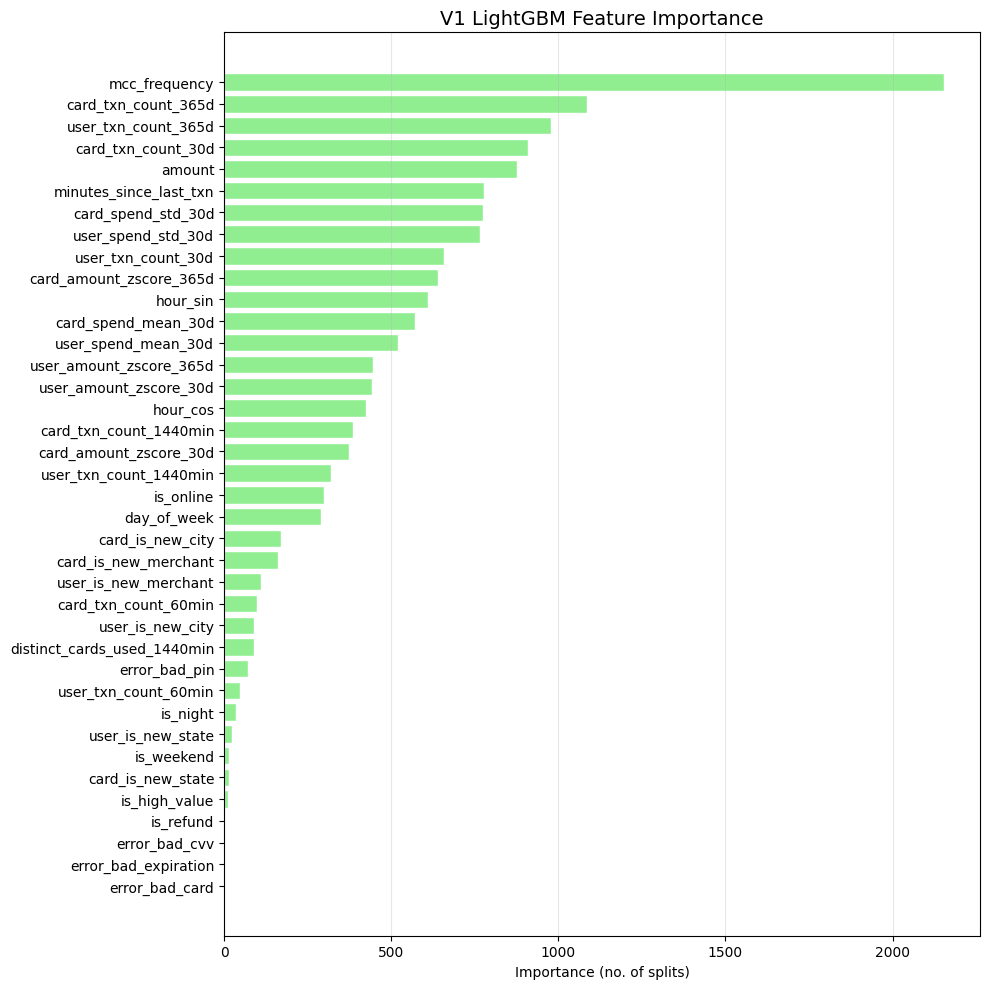


Top 10 features :
mcc_frequency                  : 2,154
card_txn_count_365d            : 1,085
user_txn_count_365d            : 978
card_txn_count_30d             : 909
amount                         : 876
minutes_since_last_txn         : 777
card_spend_std_30d             : 774
user_spend_std_30d             : 766
user_txn_count_30d             : 658
card_amount_zscore_365d        : 640

Zero Importance Features (3) : 
error_bad_cvv
error_bad_expiration
error_bad_card


In [18]:
importance = sorted(
    zip(FEATURE_COLS, lgbm_v1.feature_importances_),
    key=lambda x : x[1],
    reverse=True
)

features = [f for f, _ in importance]
imp_values = [v for _, v in importance]

fig, ax = plt.subplots(figsize=(10, 10))

colors = ["lightgreen" if v > 0 else "red" for v in imp_values]
ax.barh(features[::-1], imp_values[::-1], color=colors[::-1], edgecolor="white")

ax.set_title("V1 LightGBM Feature Importance", fontsize=14)
ax.set_xlabel("Importance (no. of splits)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 10 features :")
for f, v in importance[:10]:
    print(f"{f:<30} : {v:,}")

zero_imp = [f for f, v in importance if v == 0]
print(f"\nZero Importance Features ({len(zero_imp)}) : ")
for f in zero_imp:
    print(f"{f}")

## Isolation Forest

### Training & Scores

In [19]:
from sklearn.ensemble import IsolationForest

ISO_CONTAMINATION = config["model"]["isolation_forest"]["contamination"]
ISO_N_ESTIMATORS = config["model"]["isolation_forest"]["n_estimators"]

print("Training Isolation Forest on full training data (V1) ...")
print(f"Training : {len(x_train):,} Rows")

iso_forest = IsolationForest(
    contamination = ISO_CONTAMINATION,
    n_estimators = ISO_N_ESTIMATORS,
    random_state = RANDOM_STATE,
    n_jobs = -1
)

iso_forest.fit(x_train)
print("\nIsolation Forest Trained")

# Raw Anomaly Scores on full Val
# High score- more anomalous, Low score- more normal
raw_iso_val = -iso_forest.decision_function(x_val)  # Inverting

raw_iso_min = raw_iso_val.min()
raw_iso_max = raw_iso_val.max()

print("\nRaw Anomaly Score on Val :")
print(f"Mean : {raw_iso_val.mean():.5f}")
print(f"Std : {raw_iso_val.std():.5f}")
print(f"Min : {raw_iso_min:.5f}")
print(f"Max : {raw_iso_max:.5f}")

# Normalizing raw scores
norm_iso_val = (raw_iso_val - raw_iso_min) / (raw_iso_max - raw_iso_min)

print("\nNormalized Anomaly Score on Val :")
print(f"Mean : {norm_iso_val.mean():.5f}")
print(f"Std : {norm_iso_val.std():.5f}")
print(f"Min : {norm_iso_val.min():.5f}")
print(f"Max : {norm_iso_val.max():.5f}")

Training Isolation Forest on full training data (V1) ...
Training : 8,966,456 Rows

Isolation Forest Trained

Raw Anomaly Score on Val :
Mean : -0.15885
Std : 0.04441
Min : -0.22794
Max : 0.15032

Normalized Anomaly Score on Val :
Mean : 0.18265
Std : 0.11741
Min : 0.00000
Max : 1.00000


### Isolation Forest Fraud Signal

In [20]:
iso_fraud_mean = norm_iso_val[y_val == 1].mean()
iso_non_fraud_mean = norm_iso_val[y_val == 0].mean()
iso_pr_auc = average_precision_score(y_val, norm_iso_val)

print("Isolation Forest on Val :")
print(f"Fraud Mean Anomaly Score : {iso_fraud_mean:.5f}")
print(f"Non-Fraud Mean Anomaly Score : {iso_non_fraud_mean:.5f}")
print(f"Isolation Forest PR-AUC : {iso_pr_auc:.5f}")

Isolation Forest on Val :
Fraud Mean Anomaly Score : 0.39452
Non-Fraud Mean Anomaly Score : 0.18256
Isolation Forest PR-AUC : 0.00315


# Hybrid Weights & Threshold

## Hybrid Weights

In [21]:
print("Calculating Hybrid Weights ...")
print(f"Isolation Forest PR-AUC : {iso_pr_auc:.5f}")
print(f"LightGBM PR-AUC : {lgbm_v1_val_metrics['pr_auc']:.5f}\n")

weights = []
for w1 in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    w2 = round(1 - w1, 1)
    hybrid_scores = w1 * lgbm_v1_val_prob + w2 * norm_iso_val
    pr_auc = average_precision_score(y_val, hybrid_scores)
    roc_auc = roc_auc_score(y_val, hybrid_scores)

    weights.append({
        "lgbm_weight" : w1,
        "iso_weight" : w2,
        "pr_auc" : round(pr_auc, 5),
        "roc_auc" : round(roc_auc, 5)
    })

weight_df = pd.DataFrame(weights).sort_values("pr_auc", ascending=False)
print(weight_df.to_string(index=False))

best_weights = weight_df.iloc[0]
BEST_LGBM_WEIGHT = float(best_weights["lgbm_weight"])
BEST_ISO_WEIGHT = float(best_weights["iso_weight"])

print("\nBest Weights :-")
print(f"LightGBM Weight - {BEST_LGBM_WEIGHT}")
print(f"Isolation Forest Weight - {BEST_ISO_WEIGHT}")

print(f"\nLightGBM PR-AUC : {lgbm_v1_val_metrics['pr_auc']:.5f}")
print(f"Hybrid PR-AUC : {best_weights['pr_auc']:.5f}")
print(f"Delta : {best_weights['pr_auc'] - lgbm_v1_val_metrics['pr_auc']:+.5f}")

if BEST_ISO_WEIGHT == 0.00:
    print("\nIsolation Forest adds no value, LightGBM alone is better than hybrid")

Calculating Hybrid Weights ...
Isolation Forest PR-AUC : 0.00315
LightGBM PR-AUC : 0.27048

 lgbm_weight  iso_weight  pr_auc  roc_auc
         1.0         0.0 0.27048  0.97891
         0.9         0.1 0.08106  0.97852
         0.8         0.2 0.04736  0.97638
         0.7         0.3 0.03412  0.97434
         0.6         0.4 0.02657  0.97224
         0.5         0.5 0.02142  0.96991

Best Weights :-
LightGBM Weight - 1.0
Isolation Forest Weight - 0.0

LightGBM PR-AUC : 0.27048
Hybrid PR-AUC : 0.27048
Delta : +0.00000

Isolation Forest adds no value, LightGBM alone is better than hybrid


### Saving to Config

In [22]:
config["model"]["hybrid"]["lgbm_weight"] = BEST_LGBM_WEIGHT
config["model"]["hybrid"]["iso_weight"] = BEST_ISO_WEIGHT

with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Weights saved to config.yaml")

Weights saved to config.yaml


## Threshold Optimization

In [24]:
# Using only LightGBM Model
RECALL_FLOOR = 0.75

fraud_amount_val = v1_val.loc[y_val == 1, "amount"].values
FP_COST = 2.00

fraud_prob_val = lgbm_v1_val_prob[y_val == 1]
non_fraud_prob_val = lgbm_v1_val_prob[y_val == 0]

print("Optimising Threshold on V1 Val :-")
print("False Negative Cost : Actual Transaction Amount")
print(f"False Positive Cost : ${FP_COST:.2f} per False Alarms")
print(f"Recall Floor (minimun) : {RECALL_FLOOR}")

print(f"\nFruad transactions in Val : {len(fraud_amount_val):,}")
print(f"Average Fraud Amount : ${fraud_amount_val.mean():,.2f}")
print(f"Total Fraud Amount : ${fraud_amount_val.sum():,.2f}")

thresholds = np.arange(0.1, 0.99, 0.01).round(2)

# Vectorized calculation
# Shapes = (n_threshold, n_fraud_val), (n_threshold, n_non_fraud_val)
fraud_caught = fraud_prob_val[None, :] >= thresholds[:, None]
fraud_missed = ~fraud_caught

fn_loss = (fraud_missed * fraud_amount_val[None, :]).sum(axis=1)

fp_counts = (non_fraud_prob_val[None, :] >= thresholds[:, None]).sum(axis=1)
fp_loss = fp_counts * FP_COST

total_loss = fn_loss + fp_loss

threshold_result = []
for i, threshold in enumerate(thresholds):
    preds = (lgbm_v1_val_prob >= threshold).astype(int)

    tn = int(((preds == 0) & (y_val == 0)).sum())
    fn = int(fraud_missed[i].sum())
    fp = int(fp_counts[i])
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.00

    recall = float(recall_score(y_val, preds, zero_division=0))
    precision = float(precision_score(y_val, preds, zero_division=0))
    f1 = float(f1_score(y_val, preds, zero_division=0))

    threshold_result.append({
        "threshold" : threshold,
        "total_loss" : round(total_loss[i], 2),
        "fn_loss" : round(fn_loss[i], 2),
        "fp_loss" : round(fp_loss[i], 2),
        "fn_count" : fn,
        "fp_count" : fp,
        "recall" : round(recall, 5),
        "precision" : round(precision, 5),
        "f1" : round(f1, 5),
        "fpr" : round(fpr, 5),

    })

result_df = pd.DataFrame(threshold_result)
threshold_df = result_df[result_df["recall"] >= RECALL_FLOOR]  # balancing with fpr

if len(result_df) == 0:
    print(f"\nNo threshold with recall >= {RECALL_FLOOR}")
    
else:
    best_row = threshold_df.loc[threshold_df["total_loss"].idxmin()]
    BEST_THRESHOLD = float(best_row["threshold"])
    
    print(f"\nBest Threshold : {BEST_THRESHOLD}")
    print(f"Total Loss : ${best_row['total_loss']:,.2f}")
    print(f"FN Loss : ${best_row['fn_loss']:,.2f} ({best_row['fn_count']:,.0f} frauds missed)")
    print(f"FP Loss : ${best_row['fp_loss']:,.2f} ({best_row['fp_count']:,.0f} false alarms raised)")
    print(f"\nRecall : {best_row['recall']:.5f}")
    print(f"Precision : {best_row['precision']:.5f}")
    print(f"F1 : {best_row['f1']:.5f}")
    print(f"PR-AUC : {average_precision_score(y_val, lgbm_v1_val_prob):.5f}")
    print(f"FPR : {best_row['fpr']:.5f}")

Optimising Threshold on V1 Val :-
False Negative Cost : Actual Transaction Amount
False Positive Cost : $2.00 per False Alarms
Recall Floor (minimun) : 0.75

Fruad transactions in Val : 1,388
Average Fraud Amount : $79.44
Total Fraud Amount : $110,265.11

Best Threshold : 0.95
Total Loss : $68,454.71
FN Loss : $21,258.71 (320 frauds missed)
FP Loss : $47,196.00 (23,598 false alarms raised)

Recall : 0.76945
Precision : 0.04330
F1 : 0.08198
PR-AUC : 0.27048
FPR : 0.00742


### Visualizing

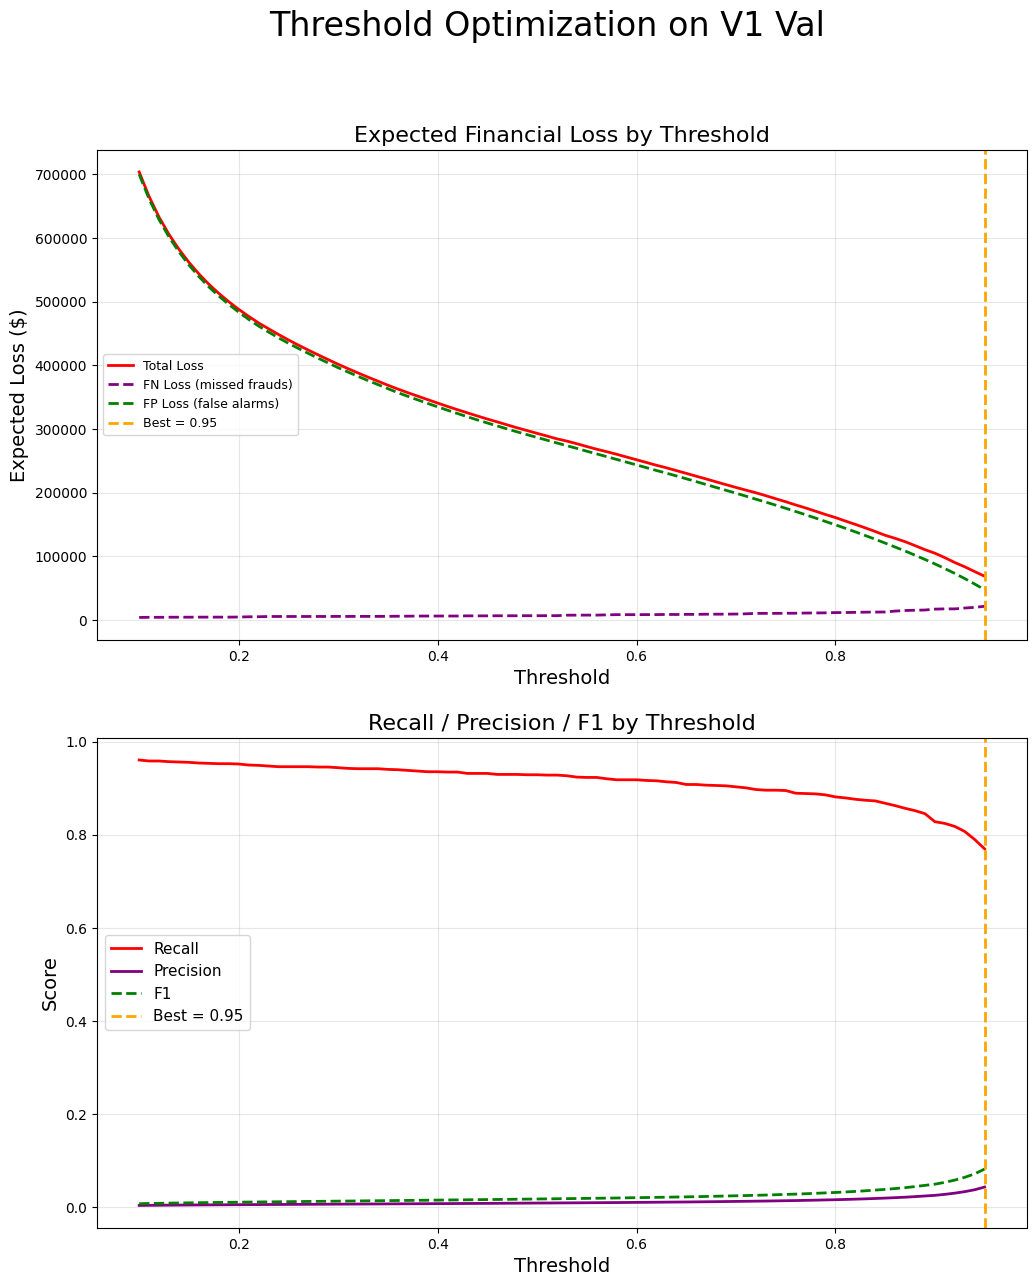

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))
fig.suptitle("Threshold Optimization on V1 Val", fontsize=24)

ax = axes[0]
ax.plot(threshold_df["threshold"], threshold_df["total_loss"], color="red",
        linewidth=2, label="Total Loss")
ax.plot(threshold_df["threshold"], threshold_df["fn_loss"], color="purple",
        linewidth=2, linestyle="--", label="FN Loss (missed frauds)")
ax.plot(threshold_df["threshold"], threshold_df["fp_loss"], color="green",
        linewidth=2, linestyle="--", label="FP Loss (false alarms)")
ax.axvline(BEST_THRESHOLD, color="orange", linewidth=2, 
           linestyle="--", label=f"Best = {BEST_THRESHOLD}")

ax.set_title("Expected Financial Loss by Threshold", fontsize=16)
ax.set_xlabel("Threshold", fontsize=14)
ax.set_ylabel("Expected Loss ($)", fontsize=14)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(threshold_df["threshold"], threshold_df["recall"], color="red",
        linewidth=2, label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["precision"], color="purple",
        linewidth=2, label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["f1"], color="green",
        linewidth=2, linestyle="--", label="F1")
ax.axvline(BEST_THRESHOLD, color="orange", linewidth=2, 
           linestyle="--", label=f"Best = {BEST_THRESHOLD}")

ax.set_title("Recall / Precision / F1 by Threshold", fontsize=16)
ax.set_xlabel("Threshold", fontsize=14)
ax.set_ylabel("Score", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.show()

### Saving to Config

In [35]:
print("Val score distribution :")
for pct in [90, 95, 99, 99.5, 99.9]:
    val = np.percentile(lgbm_v1_val_prob, pct)
    print(f"{pct}th percentile : {val:.5f}")

Val score distribution :
90th percentile : 0.11842
95th percentile : 0.43709
99th percentile : 0.93407
99.5th percentile : 0.96702
99.9th percentile : 0.98960


In [37]:
config["model"]["threshold"] = BEST_THRESHOLD
config["model"]["fp_cost"] = FP_COST
config["model"]["recall_floor"] = RECALL_FLOOR

config["risk"]["thresholds"]["low"] = round(float(np.percentile(lgbm_v1_val_prob, 90)), 3)
config["risk"]["thresholds"]["medium"] = round(float(np.percentile(lgbm_v1_val_prob, 95)), 3)
config["risk"]["thresholds"]["high"] = round(float(np.percentile(lgbm_v1_val_prob, 99)), 3)
config["risk"]["thresholds"]["critical"] = BEST_THRESHOLD

with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Saved to config.yaml")

Saved to config.yaml


# Final Evaluation on V1 Test

In [27]:
lgbm_v1_val_prob, lgbm_v1_val_metrics = evaluate_model(
    lgbm_v1, x_val, y_val,
    threshold=BEST_THRESHOLD,
    split_name="V1 Final Val"
)

lgbm_v1_test_prob, lgbm_v1_test_metrics = evaluate_model(
    lgbm_v1, x_test, y_test,
    threshold=BEST_THRESHOLD,
    split_name="V1 Final Test"
)

print("\n\nFinal V1 Evaluation (full Test) :")
print(f"Threshold = {BEST_THRESHOLD}")

print(f"\n{'Metric':<18} {'V1 Test':>12} {'V1 Val':>12} {'Delta':>12}")
for metric in [
    "pr_auc", "roc_auc", "f1", "recall", "precision", "fpr", "recall_at_0.1%fpr",
    "recall_at_1%fpr", "precision_top_1k", "precision_top_5k", "precision_top_10k"
]:
    v1_val_metric = lgbm_v1_val_metrics.get(metric, 0.0)
    v1_test_metric = lgbm_v1_test_metrics[metric]
    delta = v1_test_metric - v1_val_metric
    print(f"{metric:<18} {v1_test_metric:>12.5f} {v1_val_metric:>12.5f} {delta:>+12.5f}")

V1 Final Val Evaluation (threshold = 0.95):

pr_auc             : 0.27048
roc_auc            : 0.97891
f1                 : 0.08198
recall             : 0.76945
precision          : 0.04330
fpr                : 0.00742
recall_at_0.1%fpr  : 0.48775
recall_at_1%fpr    : 0.80476
precision_top_1k   : 0.39400
precision_top_5k   : 0.14860
precision_top_10k  : 0.08970
V1 Final Test Evaluation (threshold = 0.95):

pr_auc             : 0.66152
roc_auc            : 0.99072
f1                 : 0.18982
recall             : 0.90912
precision          : 0.10597
fpr                : 0.00709
recall_at_0.1%fpr  : 0.76254
recall_at_1%fpr    : 0.92182
precision_top_1k   : 0.89000
precision_top_5k   : 0.45620
precision_top_10k  : 0.25720


Final V1 Evaluation (full Test) :
Threshold = 0.95

Metric                  V1 Test       V1 Val        Delta
pr_auc                  0.66152      0.27048     +0.39104
roc_auc                 0.99072      0.97891     +0.01181
f1                      0.18982      0.0819

#### Test metrics are significantly better that Val metrics.
##### This is due to temporal fraud rate difference-
##### 1. Val (2011 - 2012)  : 0.044% fraud rate -> transition period
##### 2. Test (2013 - 3014) : 0.092% fraud rate -> 2x more fraud

#### FPR confirms that the model generalizes well across all time periods.
#### There is no overfitting.

## Financial Impact

In [28]:
test_fraud_amount = v1_test.loc[y_test == 1, "amount"].values
test_fraud_prob = lgbm_v1_test_prob[y_test == 1]
test_non_fraud_prob = lgbm_v1_test_prob[y_test == 0]

test_fraud_caught = int((test_fraud_prob >= BEST_THRESHOLD).sum())
test_fraud_missed = int((test_fraud_prob < BEST_THRESHOLD).sum())
test_false_alarms = int((test_non_fraud_prob >= BEST_THRESHOLD).sum())

test_fn_loss = float(test_fraud_amount[test_fraud_prob < BEST_THRESHOLD].sum())
test_fp_loss = test_false_alarms * FP_COST
test_total_loss = test_fn_loss + test_fp_loss

print("Financial Impact on V1 Test data :")
print(f"Fraud Caught : {test_fraud_caught:,} / {len(test_fraud_amount):,} ({test_fraud_caught / len(test_fraud_amount) * 100:.2f}%)")
print(f"Fraud Missed : {test_fraud_missed:,}")
print(f"False Alarms : {test_false_alarms:,}")

print(f"\nFN Loss : ${test_fn_loss:,.2f}")
print(f"FP Loss : ${test_fp_loss:,.2f}")
print(f"Total Loss : ${test_total_loss:,.2f}")

Financial Impact on V1 Test data :
Fraud Caught : 2,791 / 3,070 (90.91%)
Fraud Missed : 279
False Alarms : 23,546

FN Loss : $38,230.60
FP Loss : $47,092.00
Total Loss : $85,322.60


## Visualization

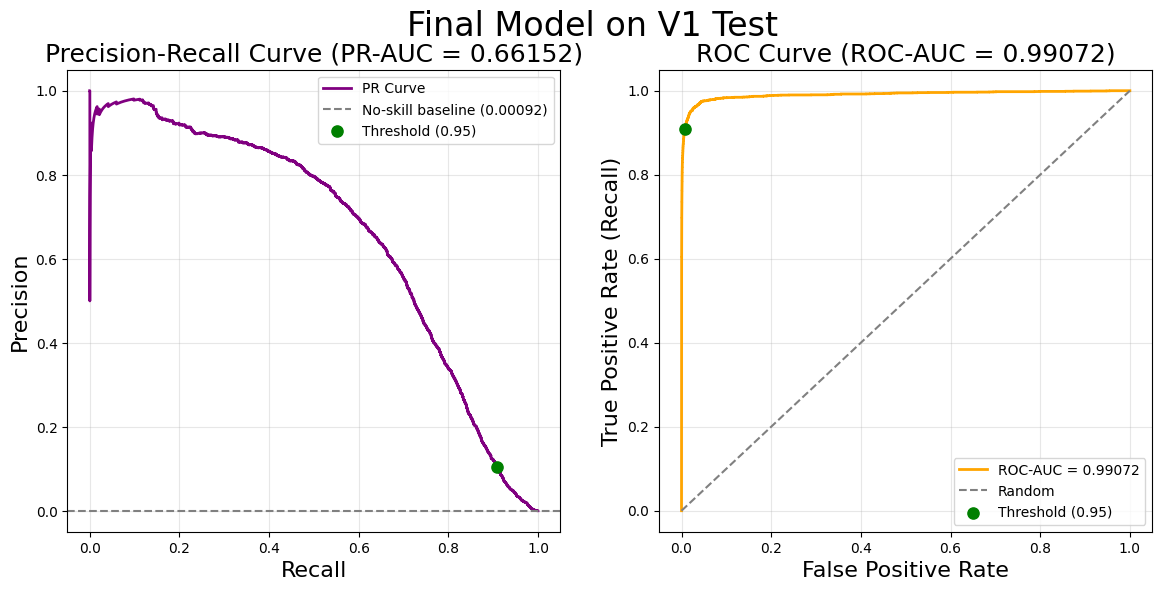

In [29]:
from sklearn.metrics import precision_recall_curve

pr_arr, rec_arr, _ = precision_recall_curve(y_test, lgbm_v1_test_prob)
fpr_arr, tpr_arr, _ = roc_curve(y_test, lgbm_v1_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Final Model on V1 Test", fontsize=24)

ax = axes[0]
ax.plot(rec_arr, pr_arr, color="purple", linewidth=2, label="PR Curve")
ax.axhline(y_test.mean(), color="gray", linestyle="--", 
        label=f"No-skill baseline ({y_test.mean():.5f})")
ax.scatter(lgbm_v1_test_metrics["recall"], lgbm_v1_test_metrics["precision"],
           color="green", s=65, zorder=5, label=f"Threshold ({BEST_THRESHOLD})")

ax.set_title(
    f"Precision-Recall Curve (PR-AUC = {lgbm_v1_test_metrics['pr_auc']:.5f})",
    fontsize=18
)
ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(fpr_arr, tpr_arr, color="orange", linewidth=2, 
        label=f"ROC-AUC = {lgbm_v1_test_metrics["roc_auc"]:.5f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
ax.scatter(lgbm_v1_test_metrics['fpr'], lgbm_v1_test_metrics['recall'], 
            color="green", s=65, zorder=5, label=f"Threshold ({BEST_THRESHOLD})")

ax.set_title(
    f"ROC Curve (ROC-AUC = {lgbm_v1_test_metrics['roc_auc']:.5f})",
    fontsize=18
)
ax.set_xlabel("False Positive Rate", fontsize=16)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=16)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.show()

#### Out of 10,000 alerts-
##### Random Classification : 9 actual frauds, 9991 false alarms (0.00092)
##### Model Classification : 1292 actual frauds, 8708 false alarms (0.12917)

#### Model is 140.4x better at identifying frauds.

## Saving Artifacts

In [38]:
ARTIFACTS_DIR = PROJECT_ROOT / config["artifacts"]["model_dir"]
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

lgbm_path = ARTIFACTS_DIR / "lgbm_v1.pkl"
iso_path = ARTIFACTS_DIR / "iso_v1.pkl"

joblib.dump(lgbm_v1, lgbm_path)
joblib.dump(iso_forest, iso_path)

print("Saved as model artifacts")

config["artifacts"]["lgbm_v1_path"] = "models/artifacts/lgbm_v1.pkl"
config["artifacts"]["iso_v1_path"] = "models/artifacts/iso_v1.pkl"

with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print("Saved paths to config")

Saved as model artifacts
Saved paths to config


# Summary

In [31]:
print("Data :")
print(f"Train ({V1_TRAIN_START} to {V1_TRAIN_END}) : {len(x_train):,} Rows")
print(f"Val ({V1_VAL_START} to {V1_VAL_END}) : {len(x_val):,} Rows")
print(f"Test ({V1_TEST_START} to {V1_TEST_END}) : {len(x_test):,} Rows")
print(f"Features : {len(FEATURE_COLS)}")

print("\nModel :")
print("Algorithm : LightGBM")
print(f"Best Iteration : {lgbm_v1.best_iteration_}")
print(f"scale_pos_weight : {SCALE_POS_WEIGHT}")
print(f"Hybrid weight : {config["model"]["hybrid"]["lgbm_weight"]}\n")
for key, value in config["model"]["lgbm"]["tuned"].items():
    print(f"{key:<18} : {value}")

print("\nIsolation Forest :")
print(f"Hybrid weight : {config["model"]["hybrid"]["iso_weight"]}")
print("Most optimal model is LightGBM only")

print(f"\nThreshold : {BEST_THRESHOLD}")
print(f"FP Cost : ${FP_COST:.2f}")
print("FN Cost : actual transaction amount")
print(f"Recall Floor : {RECALL_FLOOR}")

print(f"\nVal Metrics (threshold={BEST_THRESHOLD})")
for key, value in lgbm_v1_val_metrics.items():
    print(f"{key:<18} : {value:.5f}")

print(f"\nTest Metrics (threshold={BEST_THRESHOLD})")
for key, value in lgbm_v1_test_metrics.items():
    print(f"{key:<18} : {value:.5f}")

print("\nFinancial Impact on V1 Test :")
print(f"Fraud Caught : {test_fraud_caught:,} / {len(test_fraud_amount):,} ({test_fraud_caught / len(test_fraud_amount) * 100:.2f}%)")
print(f"False Alarms : {test_false_alarms:,}")
print(f"FN Loss : ${test_fn_loss:,.2f}")
print(f"FP Loss : ${test_fp_loss:,.2f}")
print(f"Total Loss : ${test_total_loss:,.2f}")

print("\nArtifacts :")
print(f"{lgbm_path.name}")
print(f"{iso_path.name}")

Data :
Train (1991 to 2010) : 8,966,456 Rows
Val (2011 to 2012) : 3,181,346 Rows
Test (2013 to 2014) : 3,323,230 Rows
Features : 38

Model :
Algorithm : LightGBM
Best Iteration : 193
scale_pos_weight : 649.4353
Hybrid weight : 1.0

learning_rate      : 0.017706515519014778
max_depth          : 9
n_estimators       : 950
num_leaves         : 80
feature_fraction   : 0.836965827544817
min_child_samples  : 33
reg_alpha          : 0
reg_lambda         : 1e-06

Isolation Forest :
Hybrid weight : 0.0
Most optimal model is LightGBM only

Threshold : 0.95
FP Cost : $2.00
FN Cost : actual transaction amount
Recall Floor : 0.75

Val Metrics (threshold=0.95)
pr_auc             : 0.27048
roc_auc            : 0.97891
f1                 : 0.08198
recall             : 0.76945
precision          : 0.04330
fpr                : 0.00742
recall_at_0.1%fpr  : 0.48775
recall_at_1%fpr    : 0.80476
precision_top_1k   : 0.39400
precision_top_5k   : 0.14860
precision_top_10k  : 0.08970

Test Metrics (threshold=0